In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tifffile import imread
from tifffile import imwrite
import pandas as pd
import seaborn as sns
import ipywidgets as widgets
from ipywidgets import interact
from scipy.spatial import cKDTree
from sklearn.neighbors import NearestNeighbors
from matplotlib.animation import FuncAnimation, PillowWriter

from skimage import measure

In [ ]:
image = imread(r"path_to_image_file.tif")
segpath = r"path_to_segmentation_file.tif"

In [ ]:
pixel_lat_size = 1 # in microns
pixel_axial_size = 1 # in microns
segmented_image = imread(segpath)
segmented_image = segmented_image[0:np.shape(segmented_image)[0]-1, :,:]
for i in range(segmented_image.shape[0]):
    for j in range(segmented_image.shape[1]):
        for k in range(segmented_image.shape[2]):
            if segmented_image[i,j,k] > 1:
                segmented_image[i,j,k] = 0

In [ ]:
np.shape(segmented_image)



(1216, 760, 400)

In [ ]:
labels = measure.label(segmented_image, connectivity=2)
np.shape(labels)

(1216, 760, 400)

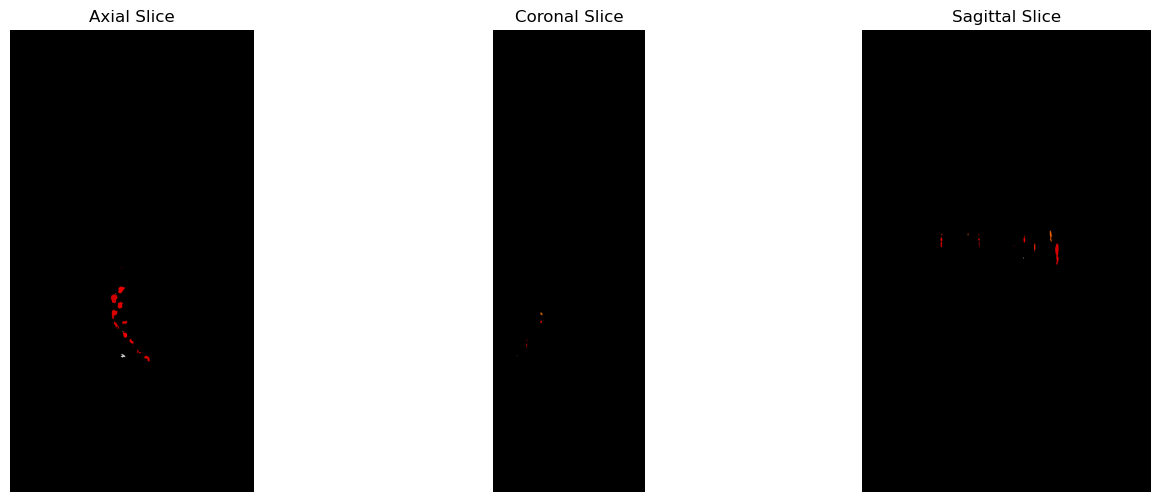

In [6]:
z_mid = labels.shape[0] // 2
y_mid = labels.shape[1] // 2
x_mid = labels.shape[2] // 2

fig, axes = plt.subplots(1, 3, figsize=(16, 6))

axes[0].imshow(labels[z_mid, :, :], cmap='nipy_spectral')
axes[0].set_title('Axial Slice')

axes[1].imshow(labels[:, y_mid, :], cmap='nipy_spectral')
axes[1].set_title('Coronal Slice')

axes[2].imshow(labels[:, :, x_mid], cmap='nipy_spectral')
axes[2].set_title('Sagittal Slice')

for ax in axes:
    ax.axis('off')

plt.show()

In [7]:
def plot_heatmap(zslice, imor):
    plt.figure(figsize=(8, 8))
    plt.imshow(labels[zslice], cmap='nipy_spectral')
    plt.title(f'Z-slice: {zslice}')
    plt.show()

interact(lambda zslice: plot_heatmap(zslice, labels), zslice=widgets.IntSlider(min=0, max=labels.shape[0]-1, step=1, value=0))

interactive(children=(IntSlider(value=0, description='zslice', max=1215), Output()), _dom_classes=('widget-int…

<function __main__.<lambda>(zslice)>

labelprops = np.empty((len(labels.flatten()), 4)) # cols = label, z, x, y

iteration = 0
for i in range(len(labels[:, 0, 0])):
    for j in range(len(labels[0, :, 0])):
        for k in range(len(labels[0, 0, :])):
            labelprops[iteration, 0] = labels[i, j, k]
            labelprops[iteration, 1] = i
            labelprops[iteration, 2] = j
            labelprops[iteration, 3] = k
            iteration += 1         


In [8]:
indices = np.where(labels != 0)
labelprops = np.column_stack((labels[indices], indices[0], indices[1], indices[2]))
label_pixel_counts = np.bincount(labels[indices].astype(int))
volume = np.multiply(label_pixel_counts, pixel_lat_size * pixel_lat_size * pixel_axial_size)
labelprops = np.column_stack((labelprops, volume[labels[indices].astype(int)]))



In [9]:
labelprops_df = pd.DataFrame(labelprops, columns=['label', 'z', 'y', 'x', 'volume']) 
labelprops_df = labelprops_df[labelprops_df['label'] != 0]

min_label_size = 50 #800px downsample, 200
label_counts = labelprops_df['label'].value_counts()
valid_labels = label_counts[label_counts >= min_label_size].index
labelprops_df = labelprops_df[labelprops_df['label'].isin(valid_labels)]

average_positions = labelprops_df.groupby('label').mean().reset_index()
print(average_positions)

coords = average_positions[['z', 'y', 'x']].values
coords_scaled = np.column_stack([
    coords[:, 0] * pixel_axial_size,
    coords[:, 1] * pixel_lat_size,
    coords[:, 2] * pixel_lat_size
])

n_neighbours = 3
nbrs = NearestNeighbors(n_neighbors=n_neighbours + 1, algorithm='auto').fit(coords_scaled)
distances, indices = nbrs.kneighbors(coords_scaled)

# Exclude the first column (distance to self, which is 0)
average_positions['mutual_distance'] = distances[:, 1:n_neighbours+1].mean(axis=1)


      label            z           y           x       volume
0       1.0     7.324074    9.179630  350.205556  177925.2480
1      11.0    14.000000   64.020619  335.824742   31960.6464
2      14.0    17.916399   60.745981  323.472669  102471.7632
3      21.0    31.433962   77.509434  313.559748  157167.3024
4      33.0    48.615721  189.717249  389.458515  301813.9392
..      ...          ...         ...         ...          ...
310  1884.0  1102.789346  609.857143   64.765133  136079.8656
311  1888.0  1098.196078  551.137255   53.176471   16804.0512
312  1889.0  1099.085271  620.775194   69.883721   42504.3648
313  1895.0  1107.864407  585.491525   28.949153   19439.9808
314  1905.0  1126.613333  554.896667   27.356667   98847.3600

[315 rows x 5 columns]


In [10]:
def plot_heatmap(zslice, imor):
    plt.figure(figsize=(8, 8))
    plt.imshow(labels[zslice], cmap='nipy_spectral') # , vmin=2, vmax=700
    plt.title(f'Z-slice: {zslice}')
    plt.scatter(average_positions[average_positions['z'].round() == zslice]['x'], average_positions[average_positions['z'].round() == zslice]['y'], c='white', s=10)
    plt.show()

interact(lambda zslice: plot_heatmap(zslice, labels), zslice=widgets.IntSlider(min=0, max=labels.shape[0]-1, step=1, value=0))

interactive(children=(IntSlider(value=0, description='zslice', max=1215), Output()), _dom_classes=('widget-int…

<function __main__.<lambda>(zslice)>

In [11]:
segmented_image = imread(segpath)

# turning into binary labelled image (1 for tissue background, 0 for everything else)
for i in range(segmented_image.shape[0]):
    for j in range(segmented_image.shape[1]):
        for k in range(segmented_image.shape[2]):
            if segmented_image[i,j,k] == 2:
                segmented_image[i,j,k] = 1
            elif segmented_image[i,j,k] != 2:
                segmented_image[i,j,k] = 0


mask = segmented_image == 1
any_mask = mask.any(axis=0)
z_idx = np.argmax(mask, axis=0)

yx_coords = np.argwhere(any_mask)
first_epi_df = pd.DataFrame({
    'z': z_idx[any_mask],
    'y': yx_coords[:, 0],
    'x': yx_coords[:, 1]
})

In [ ]:
def plot_heatmap(zslice, imor):
    plt.figure(figsize=(8, 8))
    plt.imshow(segmented_image[zslice], cmap='nipy_spectral')
    plt.scatter(first_epi_df['x'].where(first_epi_df['z'] == zslice), first_epi_df['y'].where(first_epi_df['z'] == zslice), color = "red")
    plt.title(f'Z-slice: {zslice}')
    plt.show()

interact(lambda zslice: plot_heatmap(zslice, segmented_image), zslice=widgets.IntSlider(min=0, max=segmented_image.shape[0]-1, step=1, value=0))

fig, ax = plt.subplots(figsize=(8, 8))

def update(frame):
    ax.clear()
    ax.imshow(segmented_image[frame], cmap='nipy_spectral')
    ax.scatter(first_epi_df['x'].where(first_epi_df['z'] == frame), 
               first_epi_df['y'].where(first_epi_df['z'] == frame), 
               color="red", s=1)
    ax.set_title(f'Z-slice: {frame}')
    ax.axis('off')

anim = FuncAnimation(fig, update, frames=range(0, segmented_image.shape[0], 5), interval=100)
#anim.save('C:\\Users\\2553555E\\Downloads\\epicardium_visualization.gif', writer=PillowWriter(fps=10))
plt.close()

interactive(children=(IntSlider(value=0, description='zslice', max=1216), Output()), _dom_classes=('widget-int…

In [ ]:
epi_coords = np.column_stack((
        first_epi_df['z'] * pixel_axial_size,
        first_epi_df['y'] * pixel_lat_size,
        first_epi_df['x'] * pixel_lat_size
))

label_coords = np.column_stack((
        average_positions['z'] * pixel_axial_size,
        average_positions['y'] * pixel_lat_size,
        average_positions['x'] * pixel_lat_size
))


detector_size = 100 # in square microns, adjust as needed
k_epi = int(np.sqrt(detector_size/pixel_lat_size**2))
tree = cKDTree(epi_coords)
average_positions['epi_distance'], _ = tree.query(label_coords, k=1, workers=-1)

In [14]:
print(first_epi_df)

# Build output shape large enough for both epi coordinates and spheroid labels
out_shape = (
    max(labels.shape[0], int(first_epi_df['z'].max()) + 1),
    max(labels.shape[1], int(first_epi_df['y'].max()) + 1),
    max(labels.shape[2], int(first_epi_df['x'].max()) + 1),
)

labelled_epi = np.zeros(out_shape, dtype=np.uint8)

# Only include spheroid labels with more than min_label_size voxels
label_counts = labelprops_df['label'].value_counts()
valid_labels = label_counts[label_counts >= min_label_size].index

# Find indices for valid labels only
spheroid_idx = np.argwhere(np.isin(labels, valid_labels) & (labels > 0))
labelled_epi[spheroid_idx[:, 0], spheroid_idx[:, 1], spheroid_idx[:, 2]] = 2

# Set epicardium voxels to 1, overwriting spheroid voxels if needed
for i in range(first_epi_df.shape[0]):
    z = first_epi_df.iloc[i]['z']
    y = first_epi_df.iloc[i]['y']
    x = first_epi_df.iloc[i]['x']
    labelled_epi[int(z), int(y), int(x)] = 1



          z    y    x
0         0    0  349
1         8    0  352
2         7    0  353
3         6    0  354
4         0    0  359
...     ...  ...  ...
280643  216  759  395
280644  216  759  396
280645  216  759  397
280646  215  759  398
280647  215  759  399

[280648 rows x 3 columns]


In [16]:
# macroscopic tract metrics
closest_row = average_positions.loc[average_positions['epi_distance'].idxmin()]
closest_x = (closest_row['x']/pixel_lat_size)
closest_y = int(closest_row['y']/pixel_lat_size)

print(f"Closest spheroid x, y: ({closest_x}, {closest_y})")
second_epi_df = first_epi_df.where((np.abs(first_epi_df['y'] - closest_y) <= 100) & (np.abs(first_epi_df['x'] - closest_x) <= 100))

x_um = first_epi_df["x"].to_numpy() * pixel_lat_size
y_um = first_epi_df["y"].to_numpy() * pixel_lat_size
z_um = first_epi_df["z"].to_numpy() * pixel_axial_size

A = np.column_stack((x_um, y_um, np.ones_like(x_um)))
a, b, c = np.linalg.lstsq(A, z_um, rcond=None)[0]

z_fit_um = a * x_um + b * y_um + c
rmse_um = np.sqrt(np.mean((z_um - z_fit_um) ** 2))
r2 = 1 - np.sum((z_um - z_fit_um) ** 2) / np.sum((z_um - z_um.mean()) ** 2)

# Store fitted plane and residuals (back in voxel z units for convenience)
first_epi_df["z_plane"] = z_fit_um / pixel_axial_size
first_epi_df["plane_residual_um"] = z_um - z_fit_um

# Plane normal for ax + by - z + c = 0
plane_normal = np.array([a, b, -1.0])
plane_normal /= np.linalg.norm(plane_normal)

print(f"Fitted plane: z(um) = {a:.6f}*x + {b:.6f}*y + {c:.3f}")
print(f"RMSE: {rmse_um:.3f} um, R^2: {r2:.4f}")
print("Unit normal vector [nx, ny, nz]:", plane_normal)


Closest spheroid x, y: (33.41656064461408, 0)
Fitted plane: z(um) = -0.624214*x + 0.127273*y + 1859.543
RMSE: 185.425 um, R^2: 0.9513
Unit normal vector [nx, ny, nz]: [-0.52646009  0.10734125 -0.84339649]


In [17]:
# 3D line fit (total least squares / PCA)
points_um = np.column_stack((average_positions['x'], average_positions['y'], average_positions['z'])) * np.array([pixel_lat_size, pixel_lat_size, pixel_axial_size])
line_point_um = points_um.mean(axis=0)

_, _, vh = np.linalg.svd(points_um - line_point_um, full_matrices=False)
line_direction = vh[0]  # unit direction vector of best-fit line

# Orthogonal projection of each point onto the fitted line
t = (points_um - line_point_um) @ line_direction
points_on_line_um = line_point_um + np.outer(t, line_direction)

#Fit quality (orthogonal distance to line)
line_residual_um = np.linalg.norm(points_um - points_on_line_um, axis=1)
line_rmse_um = np.sqrt(np.mean(line_residual_um**2))
line_r2 = 1 - np.sum(line_residual_um**2) / np.sum(np.linalg.norm(points_um - line_point_um, axis=1)**2)

print("Line point (um):", line_point_um)
print("Line direction [dx, dy, dz]:", line_direction)
print(f"Line RMSE: {line_rmse_um:.3f} um, R^2: {line_r2:.4f}")

Line point (um): [1788.40123908 3907.9517697  1958.95381557]
Line direction [dx, dy, dz]: [-0.34081586 -0.93238249  0.12044684]
Line RMSE: 1358.556 um, R^2: 0.6085


In [19]:
print(line_direction)
print(plane_normal)

angle = np.abs(90 - np.arccos(np.dot(line_direction, plane_normal)/(np.linalg.norm(line_direction) * np.linalg.norm(plane_normal))) * 180 / np.pi)
print(f"Angle between line and plane normal: {angle:.2f} degrees")

[-0.34081586 -0.93238249  0.12044684]
[-0.52646009  0.10734125 -0.84339649]
Angle between line and plane normal: 1.27 degrees


In [20]:
# Estimate injection tract length as the maximum distance between any two spheroid centroids

coords_um = average_positions[['z', 'y', 'x']].to_numpy(dtype=float) * np.array(
    [pixel_axial_size, pixel_lat_size, pixel_lat_size]
)

if len(coords_um) < 2:
    tract_length_um = 0.0
    print("Not enough spheroids to estimate tract length.")
else:
    diffs = coords_um[:, None, :] - coords_um[None, :, :]
    dist_matrix = np.linalg.norm(diffs, axis=2)
    i, j = np.unravel_index(np.argmax(dist_matrix), dist_matrix.shape)

    tract_length_um = dist_matrix[i, j]
    first_spheroid = average_positions.iloc[i][['z', 'y', 'x']].to_numpy()
    last_spheroid = average_positions.iloc[j][['z', 'y', 'x']].to_numpy()

    print(f"Injection tract length: {(tract_length_um/1000):.2f} mm")
    print(f"First spheroid (z, y, x): {first_spheroid}")
    print(f"Last spheroid  (z, y, x): {last_spheroid}")

Injection tract length: 7.85 mm
First spheroid (z, y, x): [  7.32407407   9.17962963 350.20555556]
Last spheroid  (z, y, x): [998.7751938  656.69767442 101.3875969 ]


In [ ]:
print(average_positions)
#average_positions.to_csv(r"\\10.7.50.250\remote_labs\Ahmed\OneDriveBACKUP\Documents\MesoSPIM\ImageData\CUBIC\H9c2_OM_4.2\H9c2_OM_4.2_average_positions.csv", index=False)

      label            z           y           x       volume  \
0       1.0     7.324074    9.179630  350.205556  177925.2480   
1      11.0    14.000000   64.020619  335.824742   31960.6464   
2      14.0    17.916399   60.745981  323.472669  102471.7632   
3      21.0    31.433962   77.509434  313.559748  157167.3024   
4      33.0    48.615721  189.717249  389.458515  301813.9392   
..      ...          ...         ...         ...          ...   
310  1884.0  1102.789346  609.857143   64.765133  136079.8656   
311  1888.0  1098.196078  551.137255   53.176471   16804.0512   
312  1889.0  1099.085271  620.775194   69.883721   42504.3648   
313  1895.0  1107.864407  585.491525   28.949153   19439.9808   
314  1905.0  1126.613333  554.896667   27.356667   98847.3600   

     mutual_distance  epi_distance  
0         621.342407     14.896904  
1         293.994948     42.040697  
2         230.995103     54.042583  
3         257.387629     65.936152  
4         344.135615    145.956383